# East River HRU Quicklook (Elevation + Soil + Landclass)

This notebook is a simple debugging-first viewer for distributed HRUs.

It is designed to be easy to follow:
- Load one config
- Read one HRU shapefile
- Optionally build a diagnostic CSV
- Plot HRUs by elevation, soil class, and land class

Use this after running the lightweight prep workflow with combined discretization:
`DOMAIN_DISCRETIZATION: elevation,soilclass,landclass`.

In [2]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import yaml

# Point to the repo root so local imports below are stable when run from VS Code.
REPO_ROOT = Path('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

# Change this to your active distributed config when needed.
CONFIG_PATH = REPO_ROOT / 'ess-project' / '0_config_files' / 'config_East_River_distributed_bigBuckt.yaml'

# Optional: set to True to regenerate HRU diagnostics CSV if missing.
AUTO_EXPORT_IF_MISSING = False

# Optional: set to True to always rebuild the HRU diagnostics CSV for fresh notebook reads.
FORCE_SUMMARY_REFRESH = True

# Optional continuous elevation bins for CSV export. Leave empty string to skip.
EXPORT_ELEVATION_BANDS = ''  # example: '2500,2800,3100,3400'

plt.style.use('default')
%matplotlib inline
print(f'Using config: {CONFIG_PATH}')

Using config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_East_River_distributed_bigBuckt.yaml


In [3]:
# Keep helper code short and explicit so debugging is easy.
# Import helper script directly from its file path because this folder name has hyphens.
import importlib.util
import re

export_script = REPO_ROOT / 'ess-project' / 'modeling' / '04-distributed' / 'export_hru_attributes.py'
spec = importlib.util.spec_from_file_location('export_hru_attributes', export_script)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
export_hru_tables = mod.export_hru_tables

def load_config(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as fp:
        return yaml.safe_load(fp) or {}


def project_dir_from_config(cfg: dict) -> Path:
    return Path(cfg['CONFLUENCE_DATA_DIR']) / f"domain_{cfg['DOMAIN_NAME']}"


def resolve_hru_shapefile(cfg: dict, project_dir: Path) -> Path:
    # Use explicit CATCHMENT_SHP_NAME when provided.
    name = cfg.get('CATCHMENT_SHP_NAME', 'default')
    if name == 'default' or not name:
        method = str(cfg.get('DOMAIN_DISCRETIZATION', 'GRUs')).replace(',', '_')
        name = f"{cfg['DOMAIN_NAME']}_HRUs_{method}.shp"

    # Keep path logic transparent: default project path unless overridden.
    catchment_path = cfg.get('CATCHMENT_PATH', 'default')
    if catchment_path == 'default' or not catchment_path:
        shp_dir = project_dir / 'shapefiles' / 'catchment'
    else:
        shp_dir = Path(catchment_path)
    return shp_dir / name


def diagnostics_dir(project_dir: Path) -> Path:
    return project_dir / 'diagnostics' / 'hru_attributes'


def resolve_intersection_shapefiles(cfg: dict, project_dir: Path) -> tuple[Path, Path]:
    soil_dir = cfg.get('INTERSECT_SOIL_PATH', 'default')
    if soil_dir == 'default' or not soil_dir:
        soil_dir = project_dir / 'shapefiles' / 'catchment_intersection' / 'with_soilgrids'
    else:
        soil_dir = Path(soil_dir)

    soil_name = cfg.get('INTERSECT_SOIL_NAME', 'catchment_with_soilclass.shp')
    if soil_name == 'default' or not soil_name:
        soil_name = 'catchment_with_soilclass.shp'
    soil_shp = soil_dir / soil_name

    land_dir = cfg.get('INTERSECT_LAND_PATH', 'default')
    if land_dir == 'default' or not land_dir:
        land_dir = project_dir / 'shapefiles' / 'catchment_intersection' / 'with_landclass'
    else:
        land_dir = Path(land_dir)

    land_name = cfg.get('INTERSECT_LAND_NAME', 'catchment_with_landclass.shp')
    if land_name == 'default' or not land_name:
        land_name = 'catchment_with_landclass.shp'
    land_shp = land_dir / land_name

    return soil_shp, land_shp


def resolve_summa_table_path(cfg: dict, project_dir: Path, table_name: str) -> Path:
    settings_dir = cfg.get('SETTINGS_SUMMA_PATH', 'default')
    if settings_dir == 'default' or not settings_dir:
        settings_dir = project_dir / 'settings' / 'SUMMA'
    else:
        settings_dir = Path(settings_dir)

    candidates = [
        Path(settings_dir) / table_name,
        REPO_ROOT / 'ess-project' / '0_base_settings' / 'SUMMA' / table_name,
        REPO_ROOT / '0_base_settings' / 'SUMMA' / table_name,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f'Could not find {table_name} in expected locations')


def parse_summa_class_lookup(table_path: Path, section_name: str) -> dict[int, str]:
    lines = table_path.read_text(encoding='utf-8').splitlines()
    in_section = False
    lookup: dict[int, str] = {}

    for raw_line in lines:
        line = raw_line.strip()
        if not line:
            continue

        if line == section_name:
            in_section = True
            continue

        if not in_section:
            continue

        if line.startswith('TOPT_DATA'):
            break

        # Match class records like:
        # 12, ... 'Barren Tundra'   OR   3 ... 'LOAM'
        match = re.match(r'^\s*(\d+)\s*,?\s+.*\'([^\']+)\'\s*$', raw_line)
        if not match:
            continue

        class_id = int(match.group(1))
        class_name = match.group(2).strip()
        lookup[class_id] = class_name

    return lookup


def load_rosetta_soil_lookup(cfg: dict, project_dir: Path) -> dict[int, str]:
    table = resolve_summa_table_path(cfg, project_dir, 'TBL_SOILPARM.TBL')
    return parse_summa_class_lookup(table, 'ROSETTA')


def load_modis_land_lookup(cfg: dict, project_dir: Path) -> dict[int, str]:
    table = resolve_summa_table_path(cfg, project_dir, 'TBL_VEGPARM.TBL')
    return parse_summa_class_lookup(table, 'MODIFIED_IGBP_MODIS_NOAH')


def dominant_class_from_columns(df: gpd.GeoDataFrame, prefixes: list[str]) -> tuple[pd.Series, list[str]]:
    class_cols = [
        col for col in df.columns
        if any(col.startswith(prefix) for prefix in prefixes)
    ]
    if not class_cols:
        return pd.Series(pd.array([pd.NA] * len(df), dtype='Int64'), index=df.index), class_cols

    numeric = df[class_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)
    dominant_col = numeric.idxmax(axis=1)
    dominant_id = dominant_col.str.extract(r'(\d+)$')[0].astype('Int64')
    return dominant_id, class_cols

In [4]:
cfg = load_config(CONFIG_PATH)
project_dir = project_dir_from_config(cfg)
hru_shp = resolve_hru_shapefile(cfg, project_dir)
soil_intersection_shp, land_intersection_shp = resolve_intersection_shapefiles(cfg, project_dir)
diag_dir = diagnostics_dir(project_dir)
summary_csv = diag_dir / 'hru_attributes_summary.csv'

if not hru_shp.exists():
    raise FileNotFoundError(f'HRU shapefile not found: {hru_shp}')

rosetta_lookup = load_rosetta_soil_lookup(cfg, project_dir)
modis_lookup = load_modis_land_lookup(cfg, project_dir)

# Export diagnostics on demand so this notebook is self-contained for review sessions.
if FORCE_SUMMARY_REFRESH or (AUTO_EXPORT_IF_MISSING and not summary_csv.exists()):
    if FORCE_SUMMARY_REFRESH:
        print('Refreshing HRU diagnostics CSV before loading...')
    else:
        print('Summary CSV not found, exporting HRU diagnostics now...')
    full_csv, summary_csv = export_hru_tables(
        config_path=CONFIG_PATH,
        variables='',
        elevation_bands=EXPORT_ELEVATION_BANDS,
        aspect_classes=False,
        outdir=''
    )
    print(f'Exported: {full_csv}')
    print(f'Exported: {summary_csv}')

hru_gdf = gpd.read_file(hru_shp)
soil_gdf = gpd.read_file(soil_intersection_shp) if soil_intersection_shp.exists() else None
land_gdf = gpd.read_file(land_intersection_shp) if land_intersection_shp.exists() else None
summary_df = pd.read_csv(summary_csv) if summary_csv.exists() else pd.DataFrame()

print(f'HRU shapefile: {hru_shp}')
print(f'HRU count (geometry): {len(hru_gdf)}')
print(f'Summary CSV: {summary_csv}')
print(f'Summary rows: {len(summary_df)}')
print(f'Soil intersection shapefile: {soil_intersection_shp} (exists={soil_intersection_shp.exists()})')
print(f'Land intersection shapefile: {land_intersection_shp} (exists={land_intersection_shp.exists()})')
print(f'ROSETTA class count: {len(rosetta_lookup)}')
print(f'MODIS class count: {len(modis_lookup)}')

# Merge summary columns onto geometry for plotting convenience.
hru_id_col = cfg.get('CATCHMENT_SHP_HRUID', 'HRU_ID')
plot_gdf = hru_gdf.copy()
if not summary_df.empty and hru_id_col in plot_gdf.columns:
    plot_gdf[hru_id_col] = plot_gdf[hru_id_col].astype(int)
    if hru_id_col in summary_df.columns:
        summary_df[hru_id_col] = summary_df[hru_id_col].astype(int)
        plot_gdf = plot_gdf.merge(summary_df, on=hru_id_col, how='left')

# Add translated labels when SUMMA index columns are present.
if 'soilTypeIndex' in plot_gdf.columns:
    soil_idx = pd.to_numeric(plot_gdf['soilTypeIndex'], errors='coerce').astype('Int64')
    plot_gdf['soil_label'] = soil_idx.map(rosetta_lookup)

if 'vegTypeIndex' in plot_gdf.columns:
    land_idx = pd.to_numeric(plot_gdf['vegTypeIndex'], errors='coerce').astype('Int64')
    plot_gdf['land_label'] = land_idx.map(modis_lookup)



Refreshing HRU diagnostics CSV before loading...
Exported: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/diagnostics/hru_attributes/hru_attributes_full.csv
Exported: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/diagnostics/hru_attributes/hru_attributes_summary.csv
HRU shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment/East_River_distributed_HRUs_elevation.shp
HRU count (geometry): 5
Summary CSV: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/diagnostics/hru_attributes/hru_attributes_summary.csv
Summary rows: 5
Soil intersection shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp (exists=True)
Land intersection shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp (exists=True)
ROSETTA class c

Elevation column: avg_elevcl
Soil column: soilTypeIndex
Land column: vegTypeIndex


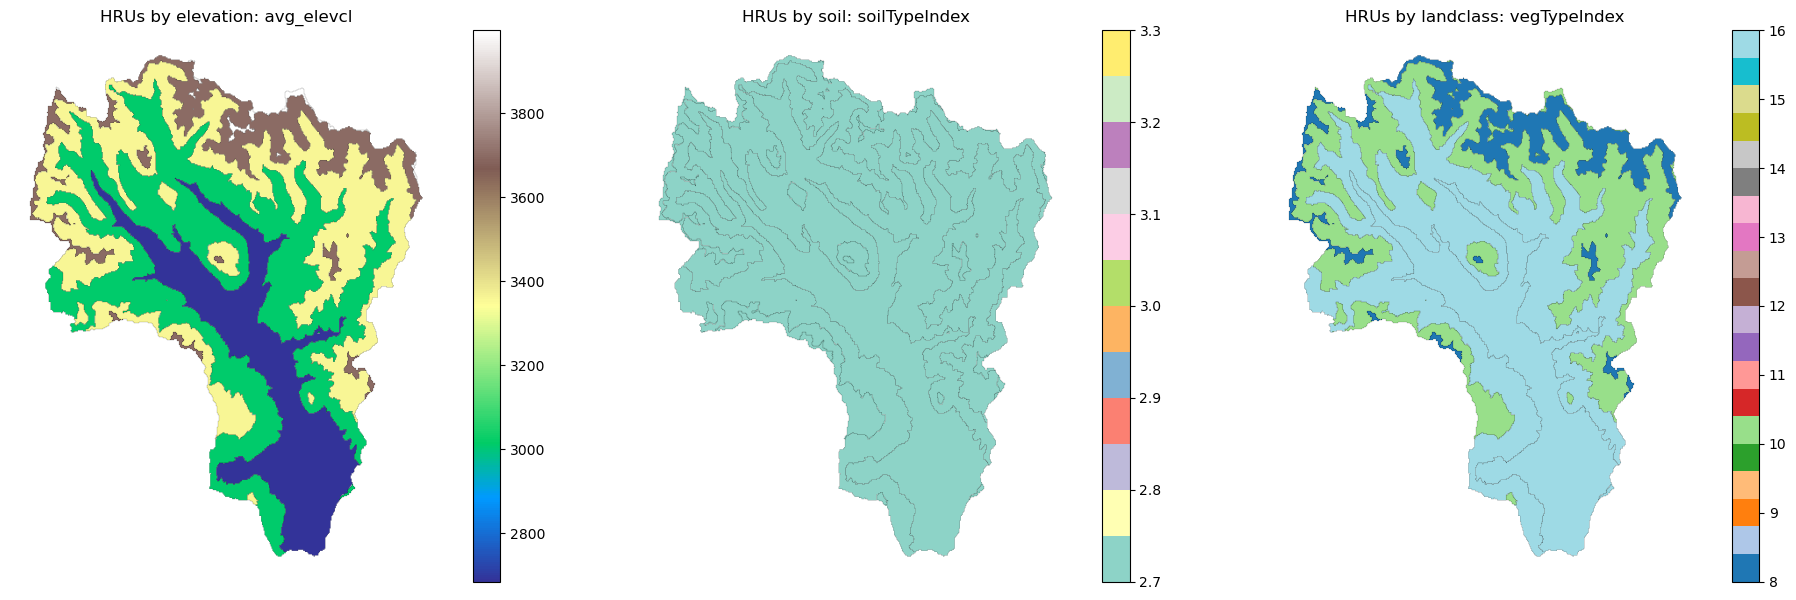

In [5]:
# Detect plotting columns with simple fallback order.
elev_col_candidates = ['avg_elevcl', 'elevation_band', 'elevation', 'elev_mean']
soil_col_candidates = ['soilClass', 'soilTypeIndex', 'soil_label']
land_col_candidates = ['landClass', 'vegTypeIndex', 'land_label']

def first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

def plot_class_map(gdf, col, ax, title, cmap):
    if col is None:
        ax.text(0.5, 0.5, 'Column missing', ha='center', va='center')
        ax.set_title(title)
        ax.set_axis_off()
        return

    # If labels are strings, encode to category codes for plotting.
    if pd.api.types.is_numeric_dtype(gdf[col]):
        plot_df = gdf
        value_col = col
    else:
        plot_df = gdf.copy()
        cat = pd.Categorical(plot_df[col].fillna('Unknown'))
        plot_df[f'{col}_code'] = cat.codes
        value_col = f'{col}_code'

    plot_df.plot(column=value_col, cmap=cmap, legend=True, ax=ax, linewidth=0.1, edgecolor='black')
    ax.set_title(f'{title}: {col}')
    ax.set_axis_off()

elev_col = first_existing(plot_gdf.columns, elev_col_candidates)
soil_col = first_existing(plot_gdf.columns, soil_col_candidates)
land_col = first_existing(plot_gdf.columns, land_col_candidates)

print('Elevation column:', elev_col)
print('Soil column:', soil_col)
print('Land column:', land_col)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
plot_class_map(plot_gdf, elev_col, axes[0], 'HRUs by elevation', 'terrain')
plot_class_map(plot_gdf, soil_col, axes[1], 'HRUs by soil', 'Set3')
plot_class_map(plot_gdf, land_col, axes[2], 'HRUs by landclass', 'tab20')
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import rasterio
from rasterio.transform import rowcol
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Paths ---
dem_path = project_dir / 'attributes' / 'elevation' / 'dem' / 'domain_East_River_distributed_elv.tif'
aspect_path = project_dir / 'attributes' / 'elevation' / 'dem' / 'domain_East_River_distributed_aspect.tif'

# --- Load DEM ---
with rasterio.open(dem_path) as src:
    dem = src.read(1).astype(float)
    nodata = src.nodata
    transform = src.transform
    crs = src.crs
    profile = src.profile.copy()
    # Build latitude array (one value per row, degrees)
    nrows, ncols = dem.shape
    # transform: (west, cell_size, 0, north, 0, -cell_size)
    cell_deg = abs(transform.e)  # degrees per cell (same in x and y for this DEM)
    lat_top = transform.f        # northing of top edge
    lats = lat_top - (np.arange(nrows) + 0.5) * cell_deg  # center lat of each row

# Mask nodata
dem[dem == nodata] = np.nan

# --- Cell sizes in metres (Horn 1981 requires metric distances) ---
# dy is fixed (degrees -> metres along a meridian)
dy_m = cell_deg * 111320.0
# dx varies with latitude: one degree longitude = 111320 * cos(lat) metres
# Shape: (nrows, 1) so it broadcasts across columns
dx_m = cell_deg * 111320.0 * np.cos(np.deg2rad(lats))[:, np.newaxis]

# --- Horn (1981) gradient — same kernel as gdaldem ---
# Pad with NaN so edges stay NaN
p = np.pad(dem, 1, mode='constant', constant_values=np.nan)

# Weights: corner cells = 1, edge cells = 2 (standard Horn)
dz_dx = (
    (p[0:-2, 2:  ] + 2 * p[1:-1, 2:  ] + p[2:  , 2:  ]) -
    (p[0:-2, 0:-2] + 2 * p[1:-1, 0:-2] + p[2:  , 0:-2])
) / (8.0 * dx_m)

dz_dy = (
    (p[2:  , 0:-2] + 2 * p[2:  , 1:-1] + p[2:  , 2:  ]) -
    (p[0:-2, 0:-2] + 2 * p[0:-2, 1:-1] + p[0:-2, 2:  ])
) / (8.0 * dy_m)

# --- Aspect: degrees clockwise from North (GDAL convention) ---
# atan2(-dz/dy, dz/dx) gives math angle (CCW from East); convert to CW from North
aspect_rad = np.arctan2(-dz_dy, dz_dx)
aspect_deg = np.degrees(aspect_rad)
# Rotate: math angle 0 = East, geographic 0 = North
aspect_cw = 90.0 - aspect_deg
# Wrap to [0, 360)
aspect_cw = np.where(aspect_cw < 0, aspect_cw + 360.0, aspect_cw)
# Flat areas (no gradient) → -9999 (matches gdaldem convention)
flat = (dz_dx == 0) & (dz_dy == 0)
aspect_cw[flat] = -9999.0
aspect_cw[np.isnan(dem)] = -9999.0

# --- Save ---
profile.update(dtype=rasterio.float32, nodata=-9999.0, count=1)
with rasterio.open(aspect_path, 'w', **profile) as dst:
    dst.write(aspect_cw.astype(np.float32), 1)
print(f'Aspect saved: {aspect_path}')

# --- Plot ---
valid = aspect_cw.copy()
valid[valid == -9999.0] = np.nan

print(f'\nAspect stats (valid pixels):')
print(f'  min: {np.nanmin(valid):.1f}°')
print(f'  max: {np.nanmax(valid):.1f}°')
print(f'  mean: {np.nanmean(valid):.1f}°')


Aspect saved: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/attributes/elevation/dem/domain_East_River_distributed_aspect.tif

Aspect stats (valid pixels):
  min: 0.0°
  max: 360.0°
  mean: 174.3°


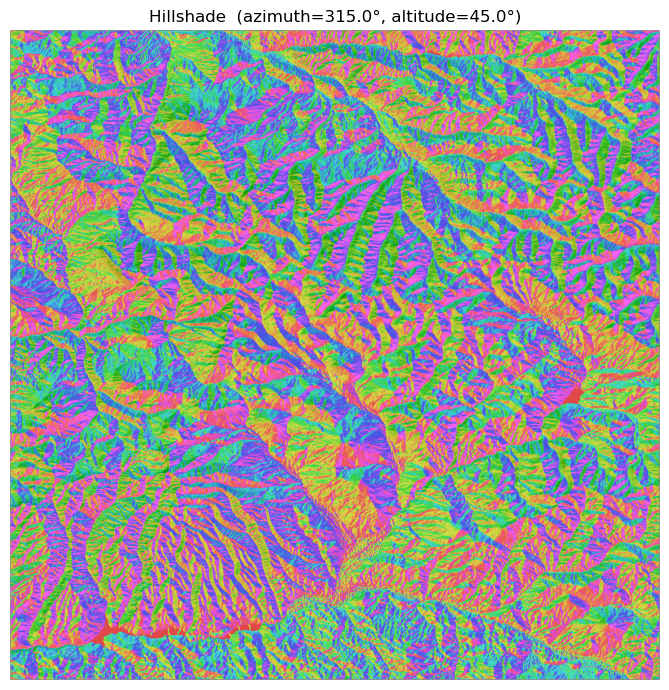

In [7]:
# --- Hillshade (reuses dz_dx / dz_dy from aspect cell above) ---
# Azimuth: 315° (NW), Altitude: 45° — standard cartographic defaults
AZIMUTH_DEG = 315.0
ALTITUDE_DEG = 45.0

# Convert to radians; azimuth is CW from North → convert to math angle (CCW from East)
az_math = np.deg2rad(360.0 - AZIMUTH_DEG + 90.0)
alt_rad = np.deg2rad(ALTITUDE_DEG)

# Slope in radians from Horn gradients
slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))

# Aspect in math convention (CCW from East) for hillshade formula
aspect_math = np.arctan2(-dz_dy, dz_dx)

# Lambertian hillshade: cos(zenith - slope * cos(az - aspect))
hillshade = (
    np.sin(alt_rad) * np.cos(slope_rad) +
    np.cos(alt_rad) * np.sin(slope_rad) * np.cos(az_math - aspect_math)
)
# Clip to [0, 1] and scale to [0, 255] (GDAL convention)
hillshade = np.clip(hillshade, 0, 1) * 255.0
hillshade[np.isnan(dem)] = np.nan

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(hillshade, cmap='gray', origin='upper', vmin=0, vmax=255)
ax.imshow(aspect_cw, cmap='hsv', origin='upper', vmin=0, vmax=360, alpha=0.6)
ax.set_title(f'Hillshade  (azimuth={AZIMUTH_DEG}°, altitude={ALTITUDE_DEG}°)')
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [8]:
# Small tabular summaries to cross-check class coverage quickly.
for label, col in [('Elevation', elev_col), ('Soil', soil_col), ('Landclass', land_col)]:
    print(f'\n=== {label} class counts ===')
    if col is None:
        print('Column missing')
        continue
    counts = plot_gdf[col].value_counts(dropna=False).sort_index()
    display(counts.to_frame(name='count'))

print('\n=== ROSETTA Soil Class Lookup (soilTypeIndex) ===')
rosetta_df = pd.DataFrame(
    sorted(rosetta_lookup.items()),
    columns=['soilTypeIndex', 'ROSETTA_class_name']
)
display(rosetta_df)

print('\n=== MODIS IGBP Landcover Lookup (vegTypeIndex) ===')
modis_df = pd.DataFrame(
    sorted(modis_lookup.items()),
    columns=['vegTypeIndex', 'MODIS_IGBP_class_name']
)
display(modis_df)

if 'soilTypeIndex' in plot_gdf.columns:
    print('\n=== Soil classes present in HRU table ===')
    present_soil = sorted(set(pd.to_numeric(plot_gdf['soilTypeIndex'], errors='coerce').dropna().astype(int).tolist()))
    present_soil_df = pd.DataFrame({
        'soilTypeIndex': present_soil,
        'ROSETTA_class_name': [rosetta_lookup.get(i, 'Unknown') for i in present_soil],
    })
    display(present_soil_df)

if 'vegTypeIndex' in plot_gdf.columns:
    print('\n=== Land classes present in HRU table ===')
    present_land = sorted(set(pd.to_numeric(plot_gdf['vegTypeIndex'], errors='coerce').dropna().astype(int).tolist()))
    present_land_df = pd.DataFrame({
        'vegTypeIndex': present_land,
        'MODIS_IGBP_class_name': [modis_lookup.get(i, 'Unknown') for i in present_land],
    })
    display(present_land_df)


=== Elevation class counts ===


,count
avg_elevcl,
2685.607521,1
3012.050333,1
3361.451095,1
3695.141568,1
3997.062072,1



=== Soil class counts ===


,count
soilTypeIndex,
3,5



=== Landclass class counts ===


...

,vegTypeIndex,MODIS_IGBP_class_name
0,1,Evergreen Needleleaf Forest
1,2,Evergreen Broadleaf Forest
2,3,Deciduous Needleleaf Forest
3,4,Deciduous Broadleaf Forest
4,5,Mixed Forests
5,6,Closed Shrublands
6,7,Open Shrublands
7,8,Woody Savannas
8,9,Savannas
9,10,Grasslands



=== Soil classes present in HRU table ===


,soilTypeIndex,ROSETTA_class_name
0,3,LOAM



=== Land classes present in HRU table ===


,vegTypeIndex,MODIS_IGBP_class_name
0,8,Woody Savannas
1,10,Grasslands
2,16,Barren or Sparsely Vegetated


In [9]:
# Optional forcing sanity check: confirm basin-averaged forcing has one series per HRU.
forcing_dir = project_dir / 'forcing' / 'basin_averaged_data'
forcing_tag = str(cfg.get('FORCING_PRODUCT_TAG', '')).strip()
forcing_dataset = str(cfg.get('FORCING_DATASET', 'METSIM'))
prefix = f"{cfg['DOMAIN_NAME']}_{forcing_dataset}"

forcing_files = sorted([p for p in forcing_dir.glob('*.nc') if p.name.startswith(prefix)])
if forcing_tag:
    forcing_files = [p for p in forcing_files if forcing_tag in p.name]
forcing_files[0]

PosixPath('/scratch/dlhogan/ess-project-data/domain_East_River_distributed/forcing/basin_averaged_data/East_River_distributed_METSIM_remapped_metsim_199910.nc')

In [10]:

if not forcing_files:
    print(f'No forcing files found in {forcing_dir} with prefix={prefix} tag={forcing_tag!r}')
else:
    sample = forcing_files[0]
    with xr.open_dataset(sample, decode_times=False) as ds:
        hru_dim = None
        for d in ['hru', 'HRU', 'nhru']:
            if d in ds.dims:
                hru_dim = d
                break

        print(f'Sample forcing file: {sample.name}')
        print(f'Dimensions: {dict(ds.dims)}')
        print(f'HRU dimension key: {hru_dim}')
        if hru_dim:
            print(f'Forcing HRU count: {int(ds.dims[hru_dim])}')
            print(f'Shapefile HRU count: {len(plot_gdf)}')
            print('Counts match:', int(ds.dims[hru_dim]) == len(plot_gdf))

Sample forcing file: East_River_distributed_METSIM_remapped_metsim_199910.nc
Dimensions: {'time': 744, 'hru': 5}
HRU dimension key: hru
Forcing HRU count: 5
Shapefile HRU count: 5
Counts match: True


/tmp/ipykernel_1279344/3145069234.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'Dimensions: {dict(ds.dims)}')
/tmp/ipykernel_1279344/3145069234.py:16: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'Forcing HRU count: {int(ds.dims[hru_dim])}')
/tmp/ipykernel_1279344/3145069234.py:18: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Counts match:', int(ds.dims[hru_dim